In [1]:
import ee
ee.Authenticate()  # this opens a browser window for login
ee.Initialize()


In [2]:
import ee
import geemap
import pandas as pd
import geopandas as gpd

# Initialize Earth Engine
try:
    ee.Initialize()
except Exception as e:
    ee.Authenticate()
    ee.Initialize()

# Define time range and Australia region
start_date = '2019-11-01'
end_date = '2020-02-29'

australia = ee.FeatureCollection("USDOS/LSIB_SIMPLE/2017") \
    .filter(ee.Filter.eq('country_na', 'Australia'))

# Load VIIRS Fire Image Collection
viirs_fires = ee.ImageCollection('NOAA/VIIRS/001/VNP14A1') \
    .filterDate(start_date, end_date) \
    .filterBounds(australia) \
    .select('MaxFRP')

# Function to convert image to fire vectors
def image_to_vectors(image):
    frp = image.select('MaxFRP')
    mask = frp.gt(0).selfMask()

    vectors = mask.reduceToVectors(
        geometry=australia.geometry(),
        scale=1000,
        geometryType='centroid',
        labelProperty='burn',
        reducer=ee.Reducer.countEvery(),
        maxPixels=1e13
    )

    return vectors.map(lambda f: f.set('date', image.date().format('YYYY-MM-dd')))

# Flatten all vector features
fire_points = viirs_fires.map(image_to_vectors).flatten()

# Pull in chunks and merge
size = fire_points.size().getInfo()
chunk_size = 3000
num_chunks = (size // chunk_size) + 1

all_features = []

for i in range(num_chunks):
    start = i * chunk_size
    end = min(start + chunk_size, size)
    sublist = fire_points.toList(count=chunk_size, offset=start)
    fc_chunk = ee.FeatureCollection(sublist)

    try:
        geojson = geemap.ee_to_geojson(fc_chunk)
        features = [{
            'lon': f['geometry']['coordinates'][0],
            'lat': f['geometry']['coordinates'][1],
            'date': f['properties'].get('date', None)
        } for f in geojson['features']]
        all_features.extend(features)
        print(f"Retrieved chunk {i + 1} with {len(features)} features.")
    except Exception as e:
        print(f"Error fetching chunk {i + 1}: {e}")

# Convert to DataFrame and save
if all_features:
    df = pd.DataFrame(all_features)
    df.to_csv('viirs_firepoints_aus_full.csv', index=False)
    print(f"Saved total {len(df)} fire points to CSV.")
else:
    print("No fire data retrieved.")

c:\Users\leeju\Downloads\cs5131proj\.conda\lib\site-packages\ee\deprecation.py:207: DeprecationWarning: 

Attention required for NOAA/VIIRS/001/VNP14A1! You are using a deprecated asset.
To make sure your code keeps working, please update it.
Learn more: https://developers.google.com/earth-engine/datasets/catalog/NOAA_VIIRS_001_VNP14A1

  warnings.warn(warning, category=DeprecationWarning)


EEException: Computation timed out.

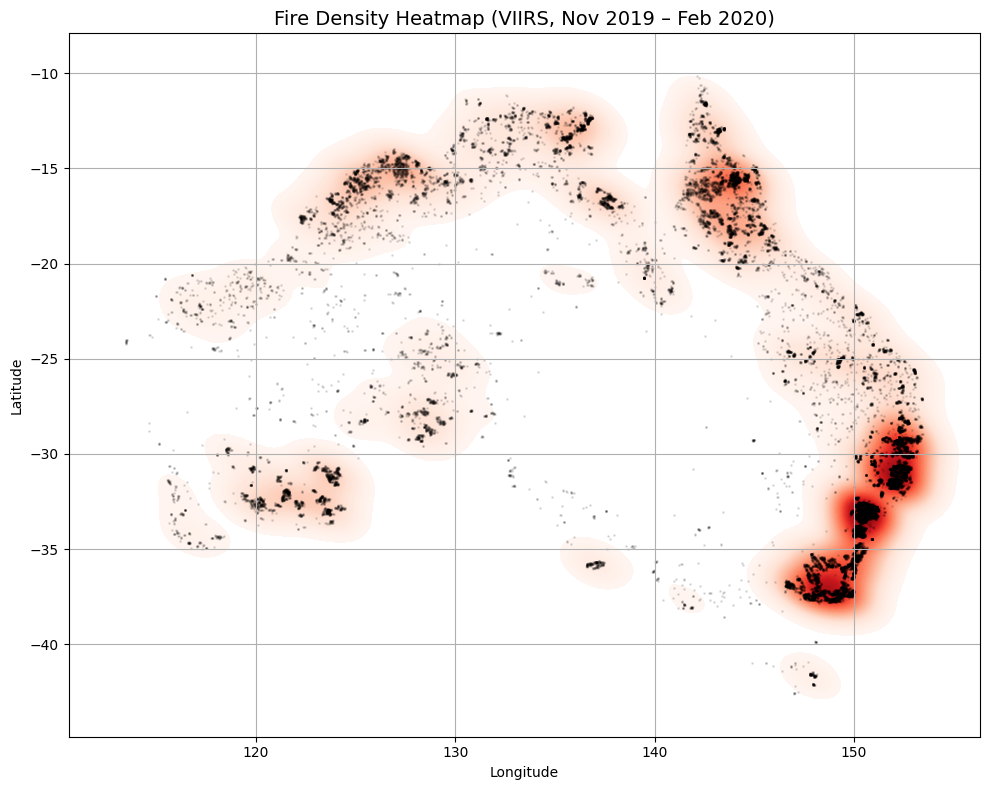

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load fire point data
df = pd.read_csv("viirs_firepoints_aus_full.csv")

# Drop rows with missing values
df = df.dropna(subset=['lat', 'lon'])

# Set up the plot
plt.figure(figsize=(10, 8))
sns.kdeplot(
    x=df['lon'], y=df['lat'],
    fill=True,
    cmap="Reds",
    bw_adjust=0.5,
    thresh=0.05,
    levels=100
)

# Overlay scatter points (optional)
plt.scatter(df['lon'], df['lat'], s=1, alpha=0.1, color='black')

# Set plot labels
plt.title("Fire Density Heatmap (VIIRS, Nov 2019 – Feb 2020)", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.grid(True)
plt.tight_layout()
##plt.savefig("fire_heatmap_matplotlib.png", dpi=300)
plt.show()
